In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
url = "https://raw.githubusercontent.com/shubhratodkar2112-cpu/CodeAlpha_CarPricePrediction/main/cardata.csv"

df = pd.read_csv(url)

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (301, 9)

Column Names:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']

Data Types:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         object
Selling_type      object
Transmission      object
Owner              int64
dtype: object

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [4]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [5]:
print("Fuel Types:")
print(df["Fuel_Type"].value_counts())

print("\nSelling Types:")
print(df["Selling_type"].value_counts())

print("\nTransmission Types:")
print(df["Transmission"].value_counts())

print("\nOwner Types:")
print(df["Owner"].value_counts())

Fuel Types:
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

Selling Types:
Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64

Transmission Types:
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

Owner Types:
Owner
0    290
1     10
3      1
Name: count, dtype: int64


In [6]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 2


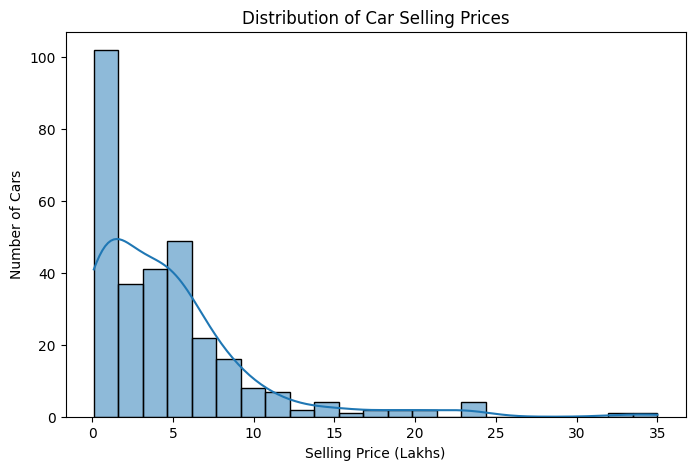

In [7]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Selling_Price"], kde=True)

plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price (Lakhs)")
plt.ylabel("Number of Cars")

plt.show()

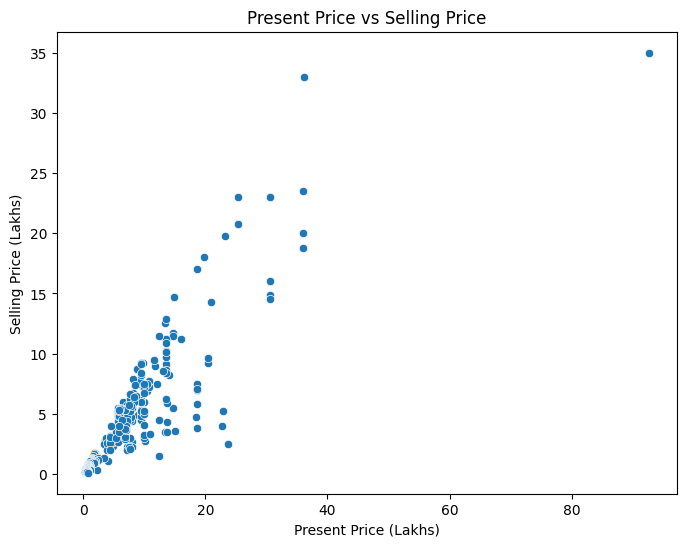

In [8]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Present_Price",
    y="Selling_Price"
)

plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price (Lakhs)")
plt.ylabel("Selling Price (Lakhs)")

plt.show()

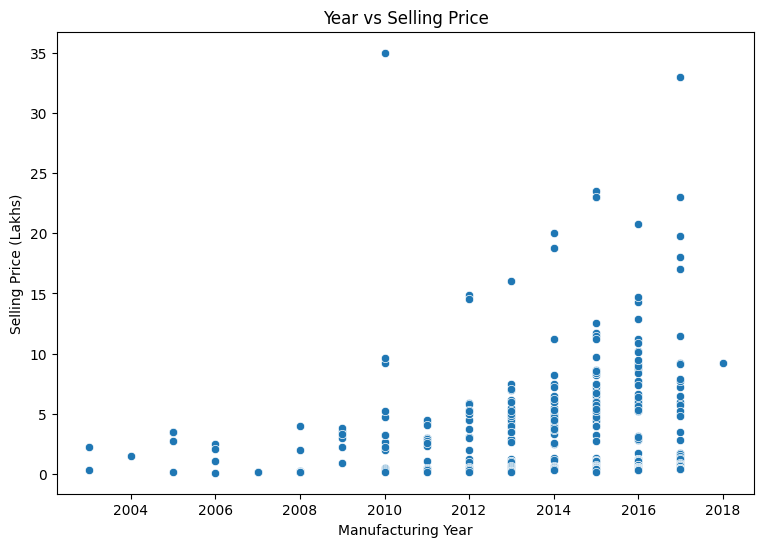

In [9]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Year",
    y="Selling_Price"
)

plt.title("Year vs Selling Price")
plt.xlabel("Manufacturing Year")
plt.ylabel("Selling Price (Lakhs)")

plt.show()

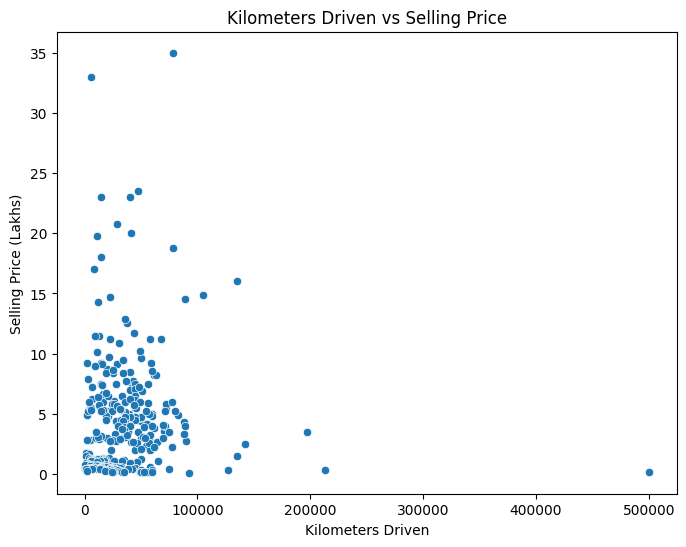

In [12]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Driven_kms",
    y="Selling_Price"
)

plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price (Lakhs)")

plt.show()

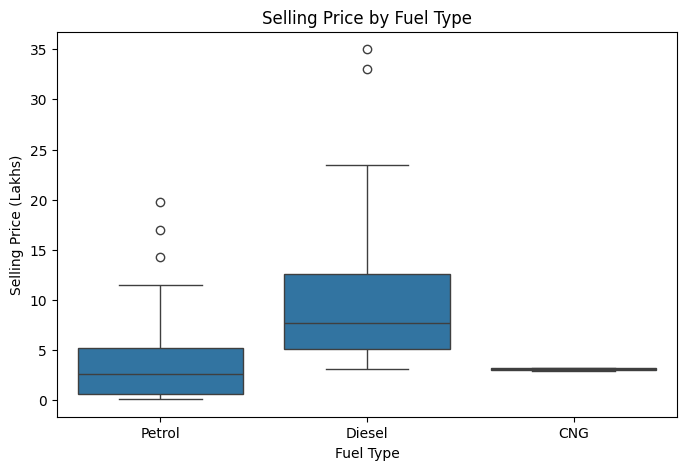

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Fuel_Type",
    y="Selling_Price"
)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price (Lakhs)")

plt.show()

In [14]:
# Create features and target

X = df.drop(columns=["Selling_Price", "Car_Name"])
y = df["Selling_Price"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Year  Present_Price  Driven_kms Fuel_Type Selling_type Transmission  Owner
0  2014           5.59       27000    Petrol       Dealer       Manual      0
1  2013           9.54       43000    Diesel       Dealer       Manual      0
2  2017           9.85        6900    Petrol       Dealer       Manual      0
3  2011           4.15        5200    Petrol       Dealer       Manual      0
4  2014           6.87       42450    Diesel       Dealer       Manual      0

Target:
0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64


In [17]:
X = pd.get_dummies(
    X,
    columns=["Fuel_Type", "Selling_type", "Transmission"],
    drop_first=True
)

print("Encoded Features:")
print(X.head())

print("\nFeature Columns:")
print(X.columns.tolist())

Encoded Features:
   Year  Present_Price  Driven_kms  Owner  Fuel_Type_Diesel  Fuel_Type_Petrol  \
0  2014           5.59       27000      0             False              True   
1  2013           9.54       43000      0              True             False   
2  2017           9.85        6900      0             False              True   
3  2011           4.15        5200      0             False              True   
4  2014           6.87       42450      0              True             False   

   Selling_type_Individual  Transmission_Manual  
0                    False                 True  
1                    False                 True  
2                    False                 True  
3                    False                 True  
4                    False                 True  

Feature Columns:
['Year', 'Present_Price', 'Driven_kms', 'Owner', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual', 'Transmission_Manual']


In [18]:
print(X.dtypes)

Year                         int64
Present_Price              float64
Driven_kms                   int64
Owner                        int64
Fuel_Type_Diesel              bool
Fuel_Type_Petrol              bool
Selling_type_Individual       bool
Transmission_Manual           bool
dtype: object


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 240
Testing samples: 61


In [20]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [21]:
y_pred_lr = lr_model.predict(X_test)

print("First 10 Actual Prices:")
print(y_test.head(10).values)

print("\nFirst 10 Predicted Prices:")
print(y_pred_lr[:10])

First 10 Actual Prices:
[ 0.35 10.11  4.95  0.15  6.95  7.45  1.1   0.5   0.45  6.  ]

First 10 Predicted Prices:
[ 2.95433731  8.17716341  6.45612271 -1.42337164  9.08864657  7.41793553
  1.33513921  0.84032259  1.36320242  7.49067757]


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression Results
-------------------------
MAE : 1.2163740193336217
RMSE: 1.865837568094988
R²  : 0.8488707839191938


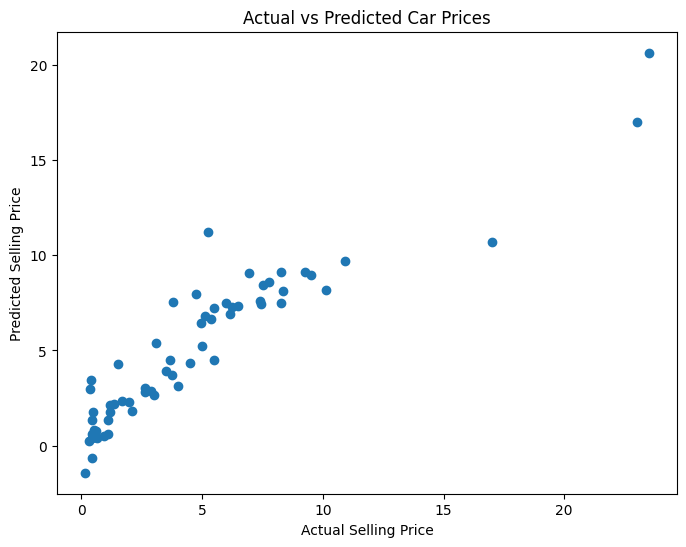

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

In [24]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regression Results")
print("--------------------------------")
print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("R²  :", r2_dt)

Decision Tree Regression Results
--------------------------------
MAE : 0.7375409836065573
RMSE: 1.1337266273550122
R²  : 0.9442021510484521


In [25]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Results")
print("--------------------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Regression Results
--------------------------------
MAE : 0.5971295081967213
RMSE: 0.906082658716206
R²  : 0.9643601062650229


In [26]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_dt,
        mae_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse_rf
    ],
    "R2 Score": [
        r2_lr,
        r2_dt,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.216374,1.865838,0.848871
1,Decision Tree,0.737541,1.133727,0.944202
2,Random Forest,0.597130,0.906083,0.964360


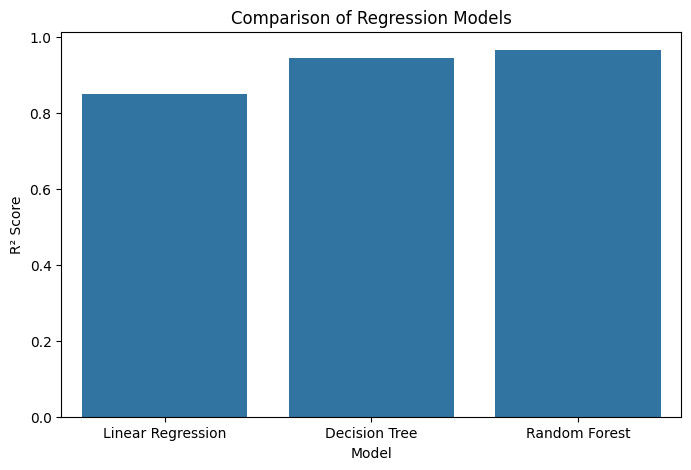

In [27]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score"
)

plt.title("Comparison of Regression Models")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.show()

In [28]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Present_Price,0.883566
0,Year,0.062012
2,Driven_kms,0.034270
7,Transmission_Manual,0.009408
5,Fuel_Type_Petrol,0.004006
6,Selling_type_Individual,0.002728
4,Fuel_Type_Diesel,0.002664
3,Owner,0.001347


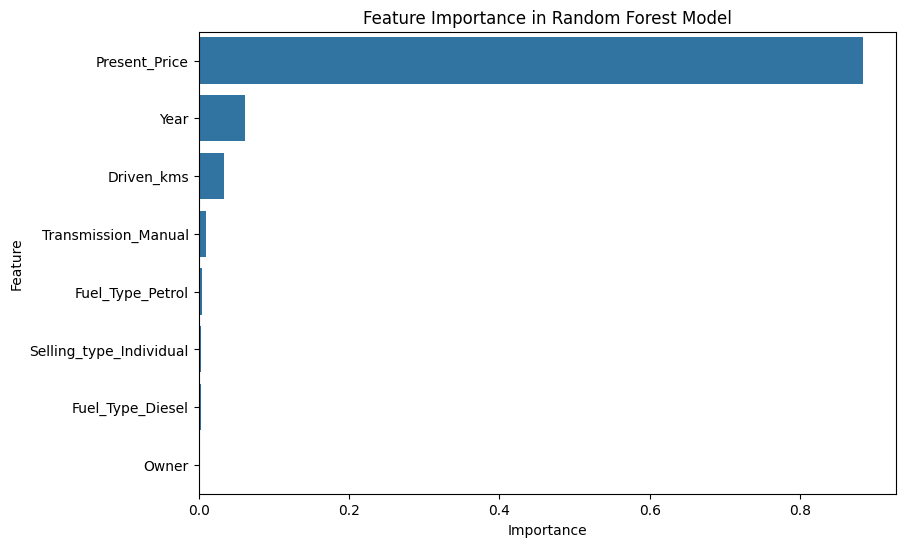

In [29]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance in Random Forest Model")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [30]:
best_model = rf_model
best_predictions = y_pred_rf

print("Final Model: Random Forest")

Final Model: Random Forest


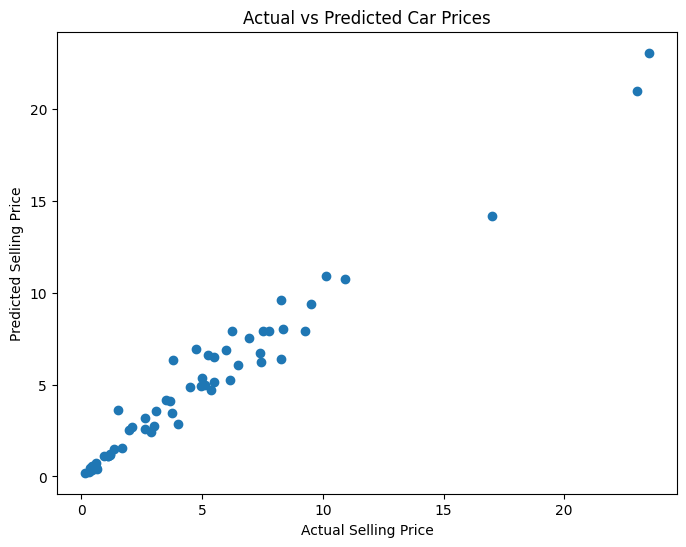

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, best_predictions)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

In [32]:
print(X.columns.tolist())

['Year', 'Present_Price', 'Driven_kms', 'Owner', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual', 'Transmission_Manual']


In [33]:
best_model = rf_model
best_predictions = y_pred_rf

print("Final Model: Random Forest")
print("R² Score:", r2_rf)

Final Model: Random Forest
R² Score: 0.9643601062650229


In [35]:
# Create a new car using the original feature values

new_car = pd.DataFrame({
    "Year": [2018],
    "Present_Price": [8.0],
    "Driven_kms": [20000],
    "Fuel_Type": ["Petrol"],
    "Selling_type": ["Dealer"],
    "Transmission": ["Manual"],
    "Owner": [0]
})

# Apply the same encoding used during training
new_car = pd.get_dummies(
    new_car,
    columns=["Fuel_Type", "Selling_type", "Transmission"],
    drop_first=True
)

# Make sure the new car has exactly the same columns and order as X
new_car = new_car.reindex(columns=X.columns, fill_value=0)

# Make prediction
predicted_price = best_model.predict(new_car)

print("Predicted Selling Price:", round(predicted_price[0], 2), "lakhs")

Predicted Selling Price: 6.21 lakhs


In [36]:
new_car = new_car.reindex(columns=X.columns, fill_value=0)

In [38]:
best_model = rf_model

## Final Prediction

The trained Random Forest Regression model was used to predict the selling price of a new car.

### Example Car Details
- Year: 2018
- Present Price: 8.0 lakhs
- Driven Kilometers: 20,000
- Fuel Type: Petrol
- Selling Type: Dealer
- Transmission: Manual
- Previous Owners: 0

### Prediction

The model predicted the selling price of the car to be approximately **6.21 lakhs**.

# 🚗 Car Price Prediction Using Machine Learning

## CodeAlpha Data Science Internship — Task 3

### 📌 Project Objective

The objective of this project is to build a machine learning regression model that predicts the selling price of a used car based on features such as present price, manufacturing year, kilometers driven, fuel type, transmission, and previous ownership.

### 🛠️ Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

### 🤖 Machine Learning Approach

The project will include:

1. Data Loading
2. Data Exploration
3. Data Cleaning
4. Exploratory Data Analysis
5. Feature Engineering
6. Categorical Data Encoding
7. Train-Test Split
8. Regression Model Training
9. Model Evaluation
10. Model Comparison
11. Price Prediction

# Conclusion

This project successfully developed a machine learning model for predicting used car selling prices.

The dataset contained information about car prices, manufacturing year, kilometers driven, fuel type, selling type, transmission, and ownership.

The data was explored, cleaned, and transformed before training multiple regression models. Linear Regression, Decision Tree Regression, and Random Forest Regression were evaluated using MAE, RMSE, and R² score.

The best-performing model was selected based on its prediction performance. The final model was also tested with a new car's specifications and successfully predicted its selling price.

This project demonstrates how machine learning can be applied to real-world car price prediction problems and can help buyers and sellers estimate reasonable resale prices.